In [102]:
import pandas as pd
import matplotlib.pyplot as plt


## Initial Test with sample data (first 10 rows of the first csv file)

In [11]:
sample_df=pd.read_csv("../data/raw/202603-citibike-tripdata_1.csv", nrows=10)
sample_df

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,A324B30D9C1F6CFE,electric_bike,2026-03-11 18:50:05.658,2026-03-11 19:02:07.383,Monroe St & Bedford Ave,4368.05,Jefferson Ave & Patchen Ave,4375.02,40.685144,-73.953809,40.686090,-73.926280,member
1,4D0D692F5FE64064,electric_bike,2026-03-08 17:39:18.215,2026-03-08 17:54:17.959,East End Ave & E 86 St,7113.08,E 77 St & 1 Ave,7020.02,40.775186,-73.944461,40.770956,-73.953562,member
2,2BEE12E018E094A5,electric_bike,2026-03-06 12:37:33.174,2026-03-06 13:03:23.951,Washington Pl & Broadway,5755.01,7 St & 3 Ave,3996.01,40.729039,-73.994046,40.672603,-73.989830,member
3,7800A32885CD2D67,electric_bike,2026-03-09 22:48:26.091,2026-03-09 23:02:24.085,Kent Ave & Grand St,5388.01,Henry St & Middagh St,4861.05,40.716425,-73.965940,40.700300,-73.991581,member
4,56D7FEABCE16E004,electric_bike,2026-03-07 13:37:15.215,2026-03-07 13:57:59.731,Monroe St & Bedford Ave,4368.05,7 St & 3 Ave,3996.01,40.685144,-73.953809,40.672603,-73.989830,member
5,2CB8CDE0E0188338,electric_bike,2026-03-12 14:22:13.955,2026-03-12 14:26:07.194,W 53 St & 10 Ave,6890.01,W 52 St & 6 Ave,6740.01,40.766697,-73.990617,40.761330,-73.979820,member
6,5617C73229A536EC,electric_bike,2026-03-06 16:11:53.616,2026-03-06 16:45:57.903,West St & Liberty St,5184.08,E 46 St & Madison Ave,6551.16,40.711444,-74.014847,40.755393,-73.977601,member
7,8C563844AB30C866,classic_bike,2026-03-13 10:18:57.147,2026-03-13 10:22:28.341,West St & Liberty St,5184.08,Park Pl & Church St,5288.08,40.711444,-74.014847,40.713342,-74.009355,member
8,D391F4A139E02B7C,electric_bike,2026-03-09 12:58:16.252,2026-03-09 13:18:01.285,39 St & Queens Blvd,6218.04,26 Ave & 2 St,7165.01,40.744310,-73.926010,40.776844,-73.934634,member
9,82BB3FD770465398,electric_bike,2026-03-10 18:10:01.034,2026-03-10 18:18:03.443,E 10 St & Ave A,5659.05,Washington Pl & 6 Ave,5838.09,40.727408,-73.981420,40.732241,-74.000264,member


In [ ]:
# Displaying the columns 
sample_df.columns

Index(['ride_id', 'rideable_type', 'started_at', 'ended_at',
       'start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
       'member_casual'],
      dtype='str')

In [ ]:
# Seeing what data types we have for each column
sample_df.dtypes

ride_id                   str
rideable_type             str
started_at                str
ended_at                  str
start_station_name        str
start_station_id      float64
end_station_name          str
end_station_id        float64
start_lat             float64
start_lng             float64
end_lat               float64
end_lng               float64
member_casual             str
dtype: object

In [ ]:
# Size of table
sample_df.shape

(10, 13)

In [19]:
sample_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ride_id             10 non-null     str    
 1   rideable_type       10 non-null     str    
 2   started_at          10 non-null     str    
 3   ended_at            10 non-null     str    
 4   start_station_name  10 non-null     str    
 5   start_station_id    10 non-null     float64
 6   end_station_name    10 non-null     str    
 7   end_station_id      10 non-null     float64
 8   start_lat           10 non-null     float64
 9   start_lng           10 non-null     float64
 10  end_lat             10 non-null     float64
 11  end_lng             10 non-null     float64
 12  member_casual       10 non-null     str    
dtypes: float64(6), str(7)
memory usage: 2.3 KB


In [18]:
sample_df.isna().sum()

ride_id               0
rideable_type         0
started_at            0
ended_at              0
start_station_name    0
start_station_id      0
end_station_name      0
end_station_id        0
start_lat             0
start_lng             0
end_lat               0
end_lng               0
member_casual         0
dtype: int64

## Timestamp Conversion

The timestamp columns were loaded as strings. They must be converted to datetime values before performing time-based calculations.

In [ ]:
#Convert from string to datetime format
sample_copy=sample_df.copy()

sample_copy["started_at"] = pd.to_datetime(sample_copy["started_at"])
sample_copy["ended_at"] = pd.to_datetime(sample_copy["ended_at"])

sample_copy.dtypes


ride_id                          str
rideable_type                    str
started_at            datetime64[us]
ended_at              datetime64[us]
start_station_name               str
start_station_id             float64
end_station_name                 str
end_station_id               float64
start_lat                    float64
start_lng                    float64
end_lat                      float64
end_lng                      float64
member_casual                    str
dtype: object

## Adding a new column with the duration of the ride

We're making 2 new columns, one for the duration of the ride overall and another one for the duration in minutes, since the rides are typically around that range.

In [ ]:
# Get the ride duration
sample_copy["ride_duration"] = (
    sample_copy["ended_at"] - sample_copy["started_at"]
)

#Turn it into minutes and round it to 2 decimal points
sample_copy["ride_duration_min"] = (sample_copy["ride_duration"].dt.total_seconds().div(60).round(2))

# Display
sample_copy["ride_duration_min"]


0    12.03
1    15.00
2    25.85
3    13.97
4    20.74
5     3.89
6    34.07
7     3.52
8    19.75
9     8.04
Name: ride_duration_min, dtype: float64

## Time-Based Feature Engineering

Extract useful time components from each ride's starting timestamp so demand can later be compared across dates, hours, and days of the week.

In [ ]:
sample_copy["start_date"]=sample_copy["started_at"].dt.date
sample_copy["start_hour"]=sample_copy["started_at"].dt.hour
sample_copy["start_day"]=sample_copy["started_at"].dt.day_name()
sample_copy["start_dayofweek"]=sample_copy["started_at"].dt.dayofweek
sample_copy["is_weekend"]=sample_copy["started_at"].dt.weekday >= 5

#sample_copy["start_date"]
#sample_copy["start_hour"]
#sample_copy["start_day"]
#sample_copy["start_dayofweek"]
#sample_copy["is_weekend"]

0    False
1     True
2    False
3    False
4     True
5    False
6    False
7    False
8    False
9    False
Name: is_weekend, dtype: bool

## Full File Loading and Validation

Applying the tested transformations to the first complete CSV and inspecting its quality before producing visualizations.

In [ ]:
# Load relevant dataset
rides1_df = pd.read_csv("../data/raw/202603-citibike-tripdata_1.csv",dtype={"start_station_id": "string","end_station_id": "string",},)

# Convert timestamp columns to datetime
rides1_df["started_at"] = pd.to_datetime(rides1_df["started_at"],errors="coerce",)
rides1_df["ended_at"] = pd.to_datetime(rides1_df["ended_at"],errors="coerce",)

# Calculate ride duration
rides1_df["ride_duration"] = (rides1_df["ended_at"] - rides1_df["started_at"])

# Convert ride duration to minutes
# Keep full precision for analysis and round only when displaying
rides1_df["ride_duration_min"] = (rides1_df["ride_duration"].dt.total_seconds().div(60))

# Add useful time-based features
rides1_df["start_date"] = rides1_df["started_at"].dt.date
rides1_df["start_hour"] = rides1_df["started_at"].dt.hour
rides1_df["start_day"] = rides1_df["started_at"].dt.day_name()
rides1_df["start_dayofweek"] = rides1_df["started_at"].dt.dayofweek
rides1_df["is_weekend"] = rides1_df["start_dayofweek"] >= 5

# Create duration flags
rides1_df["nonpositive_duration"] = (rides1_df["ride_duration_min"] <= 0)
rides1_df["long_ride"] = (rides1_df["ride_duration_min"] > 1440)

# General validation summaries
total_ride_count = len(rides1_df)
duplicate_count = rides1_df.duplicated().sum()
missing_values = rides1_df.isna().sum()

nonpositive_ride_count = rides1_df["nonpositive_duration"].sum()
long_ride_count = rides1_df["long_ride"].sum()

long_ride_percentage = (long_ride_count / total_ride_count * 100)

# Create a filtered DataFrame containing only long rides
long_rides_df = rides1_df.loc[rides1_df["long_ride"]].copy()

# Long-ride duration summary
long_ride_duration_summary = (long_rides_df["ride_duration_min"].describe())

# Longest rides with relevant columns
longest_rides = (long_rides_df[["ride_id","rideable_type","started_at","ended_at","ride_duration_min","start_station_name","end_station_name","member_casual",]].sort_values("ride_duration_min",ascending=False,).head(10))

# Compare missing end-station rates
all_rides_missing_end_station_pct = (rides1_df["end_station_name"].isna().mean()* 100)

long_rides_missing_end_station_pct = (long_rides_df["end_station_name"].isna().mean()* 100)

# Check whether long rides cluster around specific durations
long_ride_duration_frequency = (long_rides_df["ride_duration_min"].round().value_counts().head(10))

# Check whether long rides are concentrated on specific dates
long_ride_start_dates = (long_rides_df["start_date"].value_counts().sort_index())

# Long-ride composition
long_ride_membership_counts = (long_rides_df["member_casual"].value_counts())

long_ride_bike_type_counts = (long_rides_df["rideable_type"].value_counts())

# First summary tables for later graphs
rides_by_hour = (rides1_df["start_hour"].value_counts().sort_index())

rides_by_weekday = (rides1_df["start_day"].value_counts().reindex(["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday",]))

rides_by_membership = (rides1_df["member_casual"].value_counts())

rides_by_bike_type = (rides1_df["rideable_type"].value_counts())

Checking Shape

In [84]:
rides1_df.shape

(1000000, 22)

Checking missing values

In [86]:
missing_values

ride_id                    0
rideable_type              0
started_at                 0
ended_at                   0
start_station_name       576
start_station_id         576
end_station_name        2312
end_station_id          2679
start_lat                576
start_lng                576
end_lat                 2664
end_lng                 2664
member_casual              0
ride_duration              0
ride_duration_min          0
start_date                 0
start_hour                 0
start_day                  0
start_dayofweek            0
is_weekend                 0
nonpositive_duration       0
long_ride                  0
dtype: int64

Checking duplicates

In [87]:
duplicate_count

np.int64(0)

Checking details of ride duration in minutes 

In [88]:
rides1_df["ride_duration_min"].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])

count    1000000.000000
mean          12.366170
std           30.333076
min            1.000033
1%             1.439967
5%             2.385816
50%            8.394117
95%           30.953637
99%           54.969945
max         1559.933183
Name: ride_duration_min, dtype: float64

Checking long ride counts and percentages

In [89]:
long_ride_count, long_ride_percentage

(np.int64(209), np.float64(0.020900000000000002))

Checking longest rides details 

In [90]:
longest_rides

,ride_id,rideable_type,started_at,ended_at,ride_duration_min,start_station_name,end_station_name,member_casual
347793,CCC149273B770F19,classic_bike,2026-03-07 13:21:47.989,2026-03-08 15:21:43.980,1559.933183,E 97 St & 3 Ave,NaN,member
356438,611E742A25FC15CB,classic_bike,2026-03-07 19:11:20.301,2026-03-08 21:11:15.493,1559.919867,Degraw St & Hoyt St,NaN,casual
355522,F88F1A8A164F1894,classic_bike,2026-03-07 07:09:21.315,2026-03-08 09:09:16.197,1559.914700,49 Ave & 21 St,NaN,member
350188,244A6391FA69FA91,classic_bike,2026-03-07 11:06:14.815,2026-03-08 13:06:09.442,1559.910450,Emerson Pl & Myrtle Ave,NaN,casual
357052,39381066CA74C534,classic_bike,2026-03-07 15:32:49.340,2026-03-08 17:32:43.457,1559.901950,Henry St & Middagh St,NaN,casual
359648,B1C31000C6E445FA,classic_bike,2026-03-07 12:35:24.664,2026-03-08 14:35:18.512,1559.897467,12 Ave & W 40 St,NaN,casual
356297,691CF390B55F47EE,classic_bike,2026-03-07 10:23:31.167,2026-03-08 12:23:24.984,1559.896950,E 5 St & Ave C,NaN,member
360931,B9A649B0398AFA49,classic_bike,2026-03-07 16:51:45.993,2026-03-08 18:51:39.087,1559.884900,Longfellow Ave & E 165 St,NaN,casual
360903,F8658B16C39F7351,classic_bike,2026-03-07 23:17:08.569,2026-03-09 01:17:00.378,1559.863483,8 Ave & W 49 St,NaN,casual
353333,1D029F72C4DADCA9,classic_bike,2026-03-07 09:21:47.446,2026-03-08 11:21:38.656,1559.853500,Monroe St & Tompkins Ave,NaN,casual


Checking the percentage of all rides that miss an end station

In [91]:
all_rides_missing_end_station_pct

np.float64(0.2312)

Checking the percentage of long rides that miss the end station

In [92]:
long_rides_missing_end_station_pct

np.float64(94.25837320574163)

Checking the frequency at which we have long rides that last a certain duration in time

In [93]:
long_ride_duration_frequency

ride_duration_min
1500.0    184
1560.0     13
1444.0      1
1482.0      1
1488.0      1
1481.0      1
1460.0      1
1468.0      1
1470.0      1
1496.0      1
Name: count, dtype: int64

Checking the dates when people do long rides

In [94]:
long_ride_start_dates

start_date
2026-02-28    14
2026-03-01     9
2026-03-02    17
2026-03-03     5
2026-03-04    14
2026-03-05     4
2026-03-06    13
2026-03-07    13
2026-03-08    22
2026-03-09    18
2026-03-10    24
2026-03-11    18
2026-03-12     3
2026-03-13    14
2026-03-14    21
Name: count, dtype: int64

Checking the membership frequencies of the long rides

In [95]:
long_ride_membership_counts

member_casual
member    121
casual     88
Name: count, dtype: int64

Checking the type of bike frequencies for long rides

In [96]:
long_ride_bike_type_counts

rideable_type
classic_bike     206
electric_bike      3
Name: count, dtype: int64

Checking the number of rides there have been every hour

rides_by_weekday

In [97]:
rides_by_hour

start_hour
0      11349
1       7196
2       4003
3       3738
4       4139
5       8918
6      22271
7      44442
8      65940
9      51438
10     41291
11     45319
12     51121
13     56229
14     63203
15     71398
16     78976
17    101289
18     92109
19     64826
20     40993
21     30373
22     22916
23     16523
Name: count, dtype: int64

Checking the number of rides there have been each week day

In [98]:
rides_by_weekday

start_day
Monday       160045
Tuesday      161368
Wednesday    181959
Thursday      81947
Friday       143879
Saturday     139380
Sunday       131422
Name: count, dtype: int64

Checking the frequency of each membership for the overall rides

In [99]:
rides_by_membership

member_casual
member    866993
casual    133007
Name: count, dtype: int64

Checking the frequency of each bike type used for overall rides

In [100]:
rides_by_bike_type

rideable_type
electric_bike    714325
classic_bike     285675
Name: count, dtype: int64

## Rides by hour plot

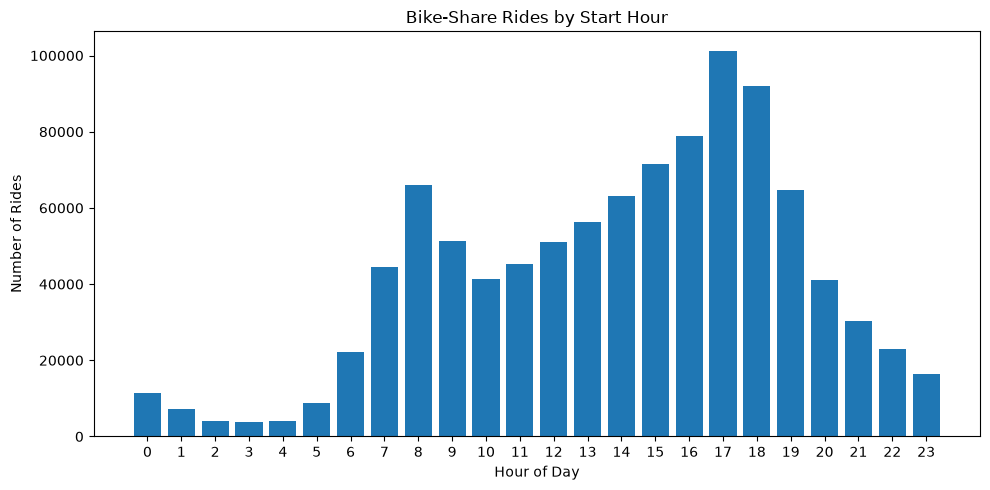

In [114]:
plt.figure(figsize=(10, 5))

plt.bar(rides_by_hour.index,rides_by_hour.values,)

plt.title("Bike-Share Rides by Start Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Rides")
plt.xticks(range(24))
plt.tight_layout()

plt.savefig( "../reports/figures/rides_by_hour_histogram.png",dpi=300,bbox_inches="tight",)

plt.show()

We can see that the peak of usage startsaround 5 pm. This reflects commute demand in the evening. Another smaller peak is around 8 am. Early hours have small demand. Let's not forget to keep in mind that the data we have used covers only part of March 2026 trips, so it does not establish a general seasonal pattern.

## Rides by weekday plot

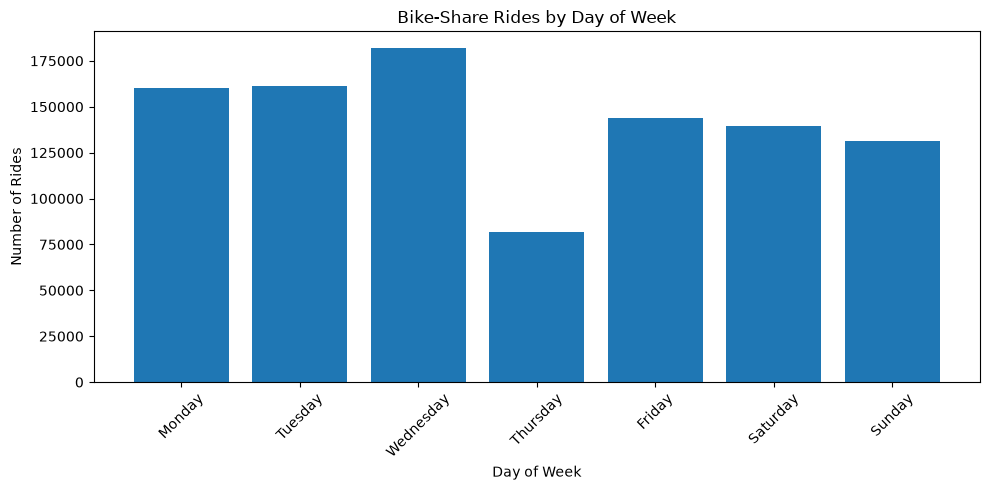

In [113]:
plt.figure(figsize=(10, 5))

plt.bar(rides_by_weekday.index,rides_by_weekday.values,)

plt.title("Bike-Share Rides by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Rides")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig( "../reports/figures/rides_by_day_of_week.png",dpi=300,bbox_inches="tight",)

plt.show()

Demand is generally constant, with a small spike on Wednesdays, and a significant dip on Thursday. We can also see that Friday, Saturday and Sunday, as a group, have slightly lower demand than the first three days of the week.

## Membership type vs number of rides

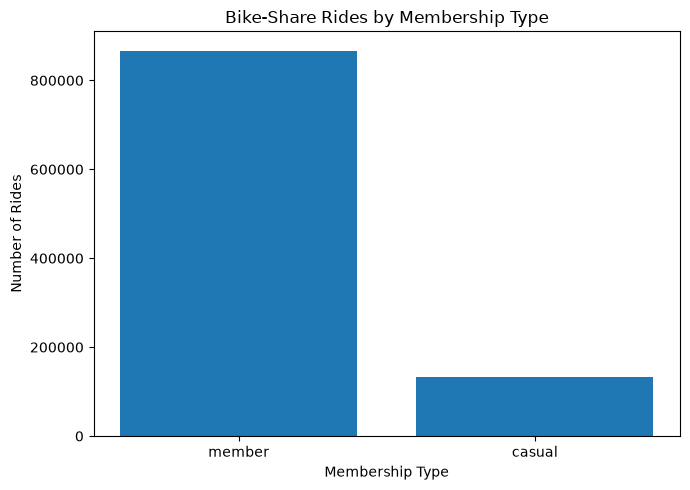

In [112]:
plt.figure(figsize=(7, 5))

plt.bar(rides_by_membership.index,rides_by_membership.values,)

plt.title("Bike-Share Rides by Membership Type")
plt.xlabel("Membership Type")
plt.ylabel("Number of Rides")
plt.tight_layout()

plt.savefig( "../reports/figures/rides_by_membership.png",dpi=300,bbox_inches="tight",)

plt.show()

Most of citi bike users are members, with a small fraction of them being casual users. 

## Bike type vs number of rides

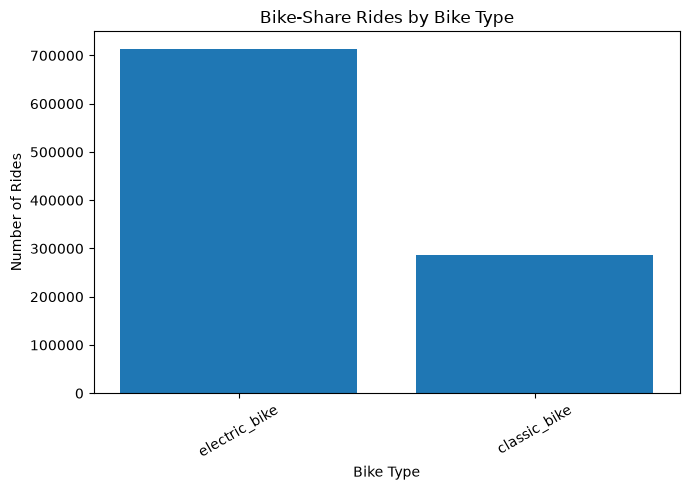

In [111]:
plt.figure(figsize=(7, 5))

plt.bar(rides_by_bike_type.index,rides_by_bike_type.values,)

plt.title("Bike-Share Rides by Bike Type")
plt.xlabel("Bike Type")
plt.ylabel("Number of Rides")
plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig( "../reports/figures/rides_by_type.png",dpi=300,bbox_inches="tight",)

plt.show()

Most citi bike users prefer the electric bike as opposed to the classic bike, which is used more than two times less.

## Line graph for bike usage with respect to time throughout one day

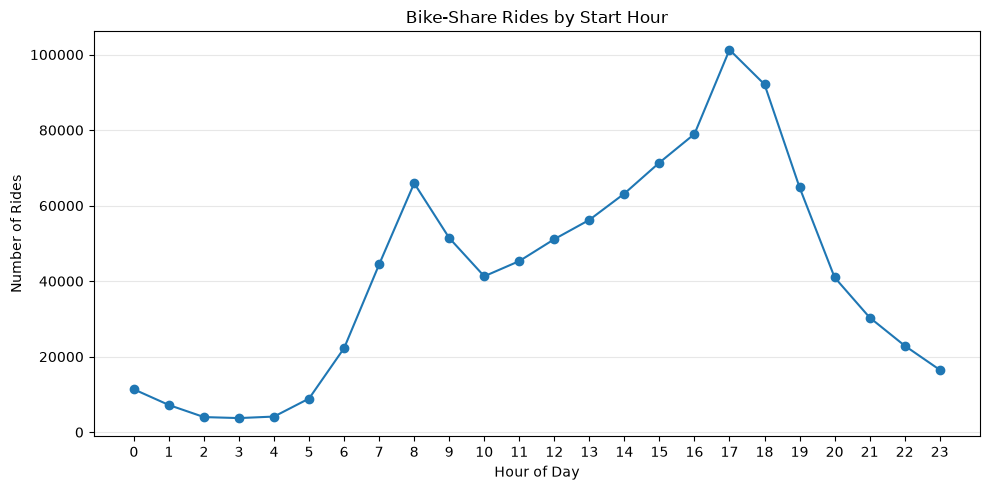

In [110]:
plt.figure(figsize=(10, 5))

plt.plot(rides_by_hour.index,rides_by_hour.values,marker="o",)

plt.title("Bike-Share Rides by Start Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Rides")
plt.xticks(range(24))
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

#Save the plot
plt.savefig( "../reports/figures/rides_by_hour.png",dpi=300,bbox_inches="tight",)

plt.show()

In [155]:
# Number of rides per hour depending if its a weekday or weekend
weekday_weekend_hourly = rides1_df.groupby(["start_hour", "is_weekend"]).size().unstack()

# Keep one row per unique date
reduced_rows = (rides1_df[["start_date", "is_weekend"]].drop_duplicates(subset="start_date"))

# Count how many unique weekday and weekend dates are present
days_by_type = (reduced_rows.groupby("is_weekend").size())

days_by_type

new_false = weekday_weekend_hourly[False] / days_by_type.loc[False]
new_true = weekday_weekend_hourly[True] / days_by_type.loc[True]

In [156]:
# Create new data frame
average_hourly_by_day_type = pd.DataFrame({"Weekday": new_false,"Weekend": new_true})
average_hourly_by_day_type

,Weekday,Weekend
start_hour,,
0,548.9,1172.0
1,320.2,798.8
2,197.0,406.6
3,141.3,465.0
4,233.9,360.0
5,763.6,256.4
6,2004.9,444.4
7,4075.4,737.6
8,5929.9,1328.2


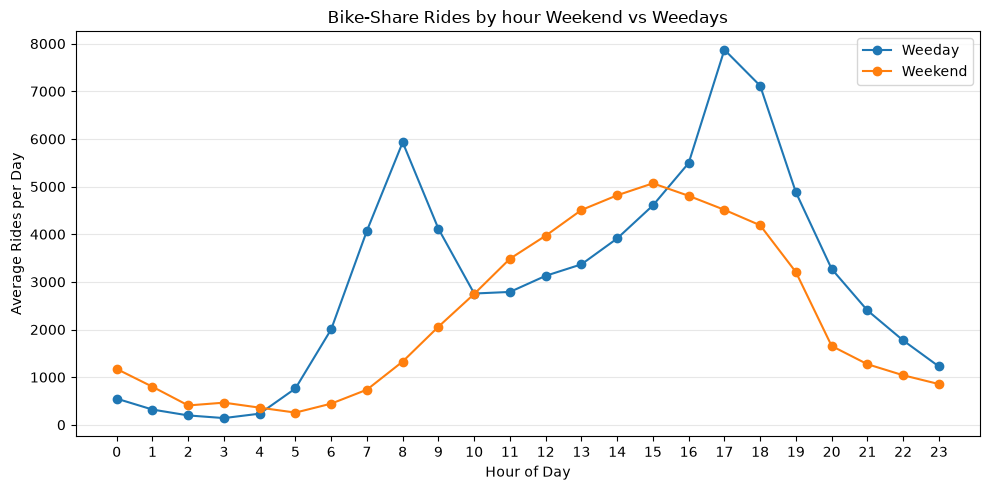

In [165]:
plt.figure(figsize=(10,5))

#Weekday values
plt.plot(average_hourly_by_day_type.index, new_false.values, marker='o', label="Weeday")
plt.plot(rides_by_hour.index, new_true.values, marker='o', label="Weekend")

plt.title("Bike-Share Rides by hour Weekend vs Weedays")
plt.xlabel("Hour of Day")
plt.ylabel("Average Rides per Day")
plt.xticks(range(24))
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

#Save the plot
plt.savefig( "../reports/figures/rides_by_hour_weekday_vs_weekend.png",dpi=300,bbox_inches="tight",)

plt.legend(loc="best")

plt.show()

Weekday demand shows two sharp peaks: one around 8 a.m. and a larger one around 5 p.m. Weekend demand has no strong morning peak and instead rises gradually toward a broad afternoon maximum around 3 p.m. This supports the idea that weekday demand is more closely associated with commuting schedules, while weekend usage may be more recreational or flexible. However, trip purpose is not directly recorded, so this remains an interpretation rather than a confirmed explanation.
